In [4]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt


results_dir = Path("results")

SIDE_LENGTH = 4
SAMPLE_SIZES = [2_000]
G_SAMPLE = 1.00

MODEL_KIND = "symm"  # "vanilla" or "symm"


def latest_file(pattern: str, directory: Path = results_dir) -> Path:
    files = sorted(directory.glob(pattern), key=lambda p: p.stat().st_mtime)
    if not files:
        raise FileNotFoundError(f"No files found for pattern: {pattern}")
    return files[-1]

In [6]:
overlap_path = latest_file(
    f"tfim_{SIDE_LENGTH}x{SIDE_LENGTH}_imbalance_overlap_{MODEL_KIND}_*.csv"
)
counts_path = latest_file(
    f"tfim_{SIDE_LENGTH}x{SIDE_LENGTH}_imbalance_counts_g{G_SAMPLE:.2f}_{MODEL_KIND}_*.csv"
)

overlap_df = pd.read_csv(overlap_path)
counts_df = pd.read_csv(counts_path)

support_df = overlap_df[overlap_df["type"] == "support"]
novel_df = overlap_df[overlap_df["type"] == "novel"]

print(f"Loaded overlap data: {overlap_path}")
print(f"Loaded imbalance counts: {counts_path}")

Loaded overlap data: results/tfim_4x4_imbalance_overlap_symm_20260604_174304.csv
Loaded imbalance counts: results/tfim_4x4_imbalance_counts_g1.00_symm_20260604_174645.csv


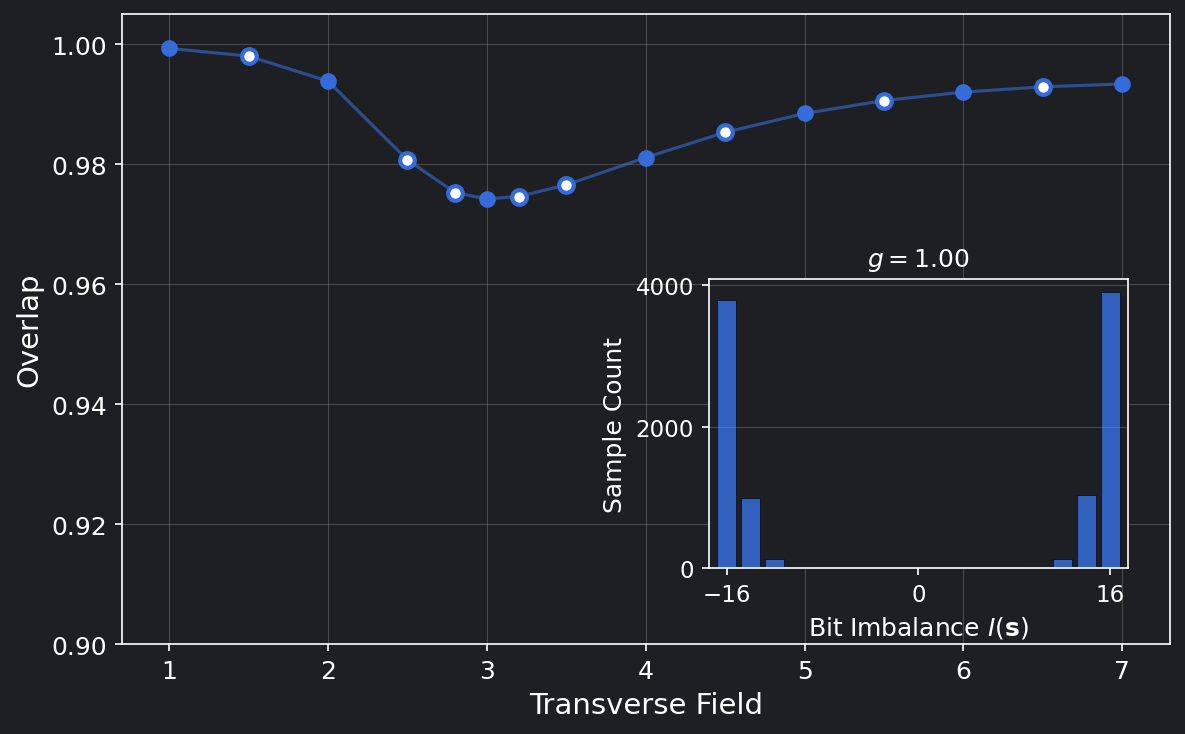

In [7]:
MAIN_LABELSIZE = 14
MAIN_TICKSIZE = 12
INSET_LABELSIZE = 12
INSET_TICKSIZE = 11
INSET_TITLESIZE = 12

fig, ax = plt.subplots(figsize=(8, 5), dpi=150)

for i, n_samples in enumerate(SAMPLE_SIZES):
    col = f"overlap_{n_samples}"

    ax.plot(overlap_df["h"], overlap_df[col], "-", color=f"C{i}", alpha=0.6)
    ax.plot(support_df["h"], support_df[col], "o", color=f"C{i}", markersize=7)
    ax.plot(novel_df["h"], novel_df[col], "o", color=f"C{i}", mfc="white",
            mew=2, markersize=7)

ax.set_xlabel("Transverse Field", fontsize=MAIN_LABELSIZE)
ax.set_ylabel("Overlap", fontsize=MAIN_LABELSIZE)
ax.set_ylim(0.90, 1.005)
ax.tick_params(axis="both", labelsize=MAIN_TICKSIZE)
ax.grid(True, alpha=0.3)

inset_ax = ax.inset_axes([0.56, 0.12, 0.40, 0.46])

inset_ax.bar(counts_df["bit_imbalance"], counts_df["count"], width=1.6, alpha=0.85,
             edgecolor="black", linewidth=0.35)

V = int(counts_df["bit_imbalance"].abs().max())

inset_ax.set_title(rf"$g={G_SAMPLE:.2f}$", fontsize=INSET_TITLESIZE)
inset_ax.set_xlabel(r"Bit Imbalance $I(\mathbf{s})$", fontsize=INSET_LABELSIZE)
inset_ax.set_ylabel("Sample Count", fontsize=INSET_LABELSIZE)

inset_ax.set_xticks([-V, 0, V])
inset_ax.set_xlim(-V - 1.5, V + 1.5)
inset_ax.set_yticks([0, 2000, 4000])
inset_ax.tick_params(axis="both", labelsize=INSET_TICKSIZE)

inset_ax.grid(True, axis="y", alpha=0.3)

fig.tight_layout()
plt.show()